# <b> Pandas로 심혈관 CSV 읽기</b>

- 목표: `pandas`로 의료 CSV를 읽고, 구조와 결측치, 기본 통계를 확인합니다.
- 연결: 이 노트북은 메인 실습의 심장병 데이터 파트로 들어가기 전에 보는 짧은 브리지입니다.


In [15]:
# Shared lecture path bootstrap
from pathlib import Path
from collections import deque
import os
import sys
import unicodedata

try:
    from google.colab import drive  # type: ignore
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except ImportError:
    pass

SEARCH_ROOTS = (
    Path("/content/drive/MyDrive/Colab Notebooks"),
    Path("/content/drive/MyDrive"),
    Path("/content/drive/Shareddrives"),
    Path.home(),
)
PROJECT_NAMES = {"00_의료 데이터 분석"}

def _norm(text: str) -> str:
    return unicodedata.normalize("NFC", text)

def _is_project_root(path: Path) -> bool:
    return (path / "00_shared" / "utils" / "lecture_paths.py").exists()

def _find_project_root() -> Path:
    override = os.environ.get("PROJECT_ROOT")
    if override:
        root = Path(override).expanduser().resolve()
        if _is_project_root(root):
            return root
        raise FileNotFoundError("환경변수 PROJECT_ROOT가 올바른 강의 루트를 가리키지 않습니다.")

    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if _is_project_root(root):
            return root

    target_names = {_norm(name) for name in PROJECT_NAMES}
    for base in SEARCH_ROOTS:
        if not base.exists():
            continue
        queue = deque([(base.resolve(), 0)])
        seen = set()
        while queue:
            current, depth = queue.popleft()
            if current in seen:
                continue
            seen.add(current)

            if _norm(current.name) in target_names and _is_project_root(current):
                return current
            if depth >= 4:
                continue

            try:
                children = [
                    child for child in current.iterdir()
                    if child.is_dir() and not child.name.startswith(".") and child.name not in {"__pycache__", ".ipynb_checkpoints"}
                ]
            except OSError:
                continue

            children.sort(key=lambda child: (_norm(child.name) not in target_names, child.name))
            queue.extend((child.resolve(), depth + 1) for child in children)

    raise FileNotFoundError(
        "PROJECT_ROOT를 찾지 못했습니다. Colab에서는 os.environ['PROJECT_ROOT']를 먼저 지정하세요."
    )

def _resolve_day_dir(name: str) -> Path:
    for candidate in {name, unicodedata.normalize("NFC", name), unicodedata.normalize("NFD", name)}:
        path = PROJECT_ROOT / candidate
        if path.exists():
            return path
    return PROJECT_ROOT / name

PROJECT_ROOT = _find_project_root()
os.environ["PROJECT_ROOT"] = str(PROJECT_ROOT)
UTILS_ROOT = PROJECT_ROOT / "00_shared" / "utils"
if str(UTILS_ROOT) not in sys.path:
    sys.path.append(str(UTILS_ROOT))

from lecture_paths import DATA_ROOT, MODEL_ROOT, ensure_dir

DAY_DIR = _resolve_day_dir('00-Data-Analysis')
DAY_OUTPUT_ROOT = ensure_dir(DAY_DIR / "99_실행산출물")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_ROOT: {DATA_ROOT}")
print(f"MODEL_ROOT: {MODEL_ROOT}")
print(f"DAY_OUTPUT_ROOT: {DAY_OUTPUT_ROOT}")


PROJECT_ROOT: /content/drive/MyDrive/00_Project/00_의료 데이터 분석
DATA_ROOT: /content/drive/MyDrive/00_Project/00_의료 데이터 분석/00_shared/datasets
MODEL_ROOT: /content/drive/MyDrive/00_Project/00_의료 데이터 분석/00_shared/models
DAY_OUTPUT_ROOT: /content/drive/MyDrive/00_Project/00_의료 데이터 분석/00-Data-Analysis/99_실행산출물


## 실행 가이드

- 로컬 실행: bootstrap 셀부터 실행하고, 출력된 `PROJECT_ROOT`, `DATA_ROOT`, `DAY_OUTPUT_ROOT`를 먼저 확인합니다.
- Colab 실행: 01일차 입문 노트북과 같은 방식으로 `PROJECT_ROOT`를 지정한 뒤 bootstrap 셀부터 실행합니다.
- 이 노트북은 `heart_disease.csv`를 기준으로 `pandas`의 최소 문법만 다룹니다.


## AI 도구 활용 체크포인트

- `df.info()`와 `df.isna().sum()` 결과가 무엇을 의미하는지 현재 쓰는 AI 도구에게 설명하게 해보고, 출력과 맞는지 직접 비교합니다.
- 컬럼명을 요약하게 할 때는 반드시 노트북 출력과 대조해 틀린 이름이 없는지 확인합니다.


# Part 1. 데이터 불러오기

## 🎯 학습 목표
- CSV를 DataFrame으로 읽는다.
- 행/열 개수와 주요 컬럼을 확인한다.


In [16]:
import pandas as pd

csv_path = DATA_ROOT / "heart_disease" / "heart_disease.csv"
df = pd.read_csv(csv_path, keep_default_na=False, na_values=[""])

print(f"csv_path: {csv_path}")
print(f"shape: {df.shape}")

csv_path: /content/drive/MyDrive/00_Project/00_의료 데이터 분석/00_shared/datasets/heart_disease/heart_disease.csv
shape: (10000, 21)


## 1. 첫 몇 행 보기

In [17]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


## 2. 컬럼과 데이터 구조 확인

In [18]:
print(df.columns.tolist())
print()
df.info()

['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level', 'Heart Disease Status']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8

## 3. 결측치 개수 확인

In [19]:
df.isna().sum().sort_values(ascending=False).head(10)

,0
Alcohol Consumption,32
Diabetes,30
Sugar Consumption,30
Cholesterol Level,30
Age,29
Triglyceride Level,26
CRP Level,26
High LDL Cholesterol,26
High Blood Pressure,26
Low HDL Cholesterol,25


# Part 2. 필요한 열만 골라보기

## 🎯 학습 목표
- 자주 보는 열만 따로 뽑는다.
- 조건으로 행을 필터링한다.


In [20]:
key_cols = ["Age", "Gender", "Blood Pressure", "Cholesterol Level", "BMI", "Heart Disease Status"]
key_df = df[key_cols].copy()
key_df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Heart Disease Status
0,56.0,Male,153.0,155.0,24.991591,No
1,69.0,Female,146.0,286.0,25.221799,No
2,46.0,Male,126.0,216.0,29.855447,No
3,32.0,Female,122.0,293.0,24.130477,No
4,60.0,Male,166.0,242.0,20.486289,No


## 📝 TODO 1

In [22]:
# 여성 환자 중 심장병이 있는 행만 골라 새로운 DataFrame을 만들어보세요.
female_yes = key_df[(key_df["Gender"] == "Female") & (key_df["Heart Disease Status"] == "Yes")].copy()
female_yes.head()

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Heart Disease Status
8000,59.0,Female,133.0,251.0,34.007264,Yes
8008,67.0,Female,123.0,208.0,29.985393,Yes
8009,60.0,Female,171.0,210.0,30.834846,Yes
8011,62.0,Female,158.0,294.0,32.559433,Yes
8015,59.0,Female,143.0,290.0,32.340786,Yes


# Part 3. 요약 통계와 범주형 분포

## 🎯 학습 목표
- 숫자형 변수의 기본 통계를 읽는다.
- 심장병 유무에 따라 평균 차이를 본다.


In [25]:
numeric_cols = ["Age", "Blood Pressure", "Cholesterol Level", "BMI", "Sleep Hours"]
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,9971.0,49.296259,18.193970,18.000000,34.000000,49.000000,65.000000,80.000000
Blood Pressure,9981.0,149.757740,17.572969,120.000000,134.000000,150.000000,165.000000,180.000000
Cholesterol Level,9970.0,225.425577,43.575809,150.000000,187.000000,226.000000,263.000000,300.000000
BMI,9978.0,29.077269,6.307098,18.002837,23.658075,29.079492,34.520015,39.996954
Sleep Hours,9975.0,6.991329,1.753195,4.000605,5.449866,7.003252,8.531577,9.999952


In [26]:
df.groupby("Heart Disease Status")[numeric_cols].mean().round(1)

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours
Heart Disease Status,,,,,
No,49.4,149.9,225.4,29.0,7.0
Yes,49.0,149.3,225.7,29.3,7.0


 ### 💡 데이터 분석 결과 해석 가이드
- **교차 표(Crosstab)**: 각 습관 그룹 내에서 'Yes'(심장병 있음)의 비율이 다른 그룹보다 유의미하게 높은지 확인합니다.
- **시각화(Countplot)**: 특정 습관(예: Smoking 'Yes' 또는 Exercise 'Low')을 가진 그룹에서 주황색 막대(Heart Disease Status: Yes)의 비중이 상대적으로 큰지 시각적으로 비교합니다.

In [32]:
pd.crosstab(df["Gender"], df["Heart Disease Status"])

Heart Disease Status,No,Yes
Gender,,
Female,3948,1030
Male,4034,969



--- Smoking vs Heart Disease Status ---


Heart Disease Status,No,Yes
Smoking,,
No,80.1,19.9
Yes,79.9,20.1



--- Alcohol Consumption vs Heart Disease Status ---


Heart Disease Status,No,Yes
Alcohol Consumption,,
High,79.0,21.0
Low,79.6,20.4
Medium,80.6,19.4
None,80.9,19.1



--- Exercise Habits vs Heart Disease Status ---


Heart Disease Status,No,Yes
Exercise Habits,,
High,80.0,20.0
Low,80.3,19.7
Medium,79.6,20.4


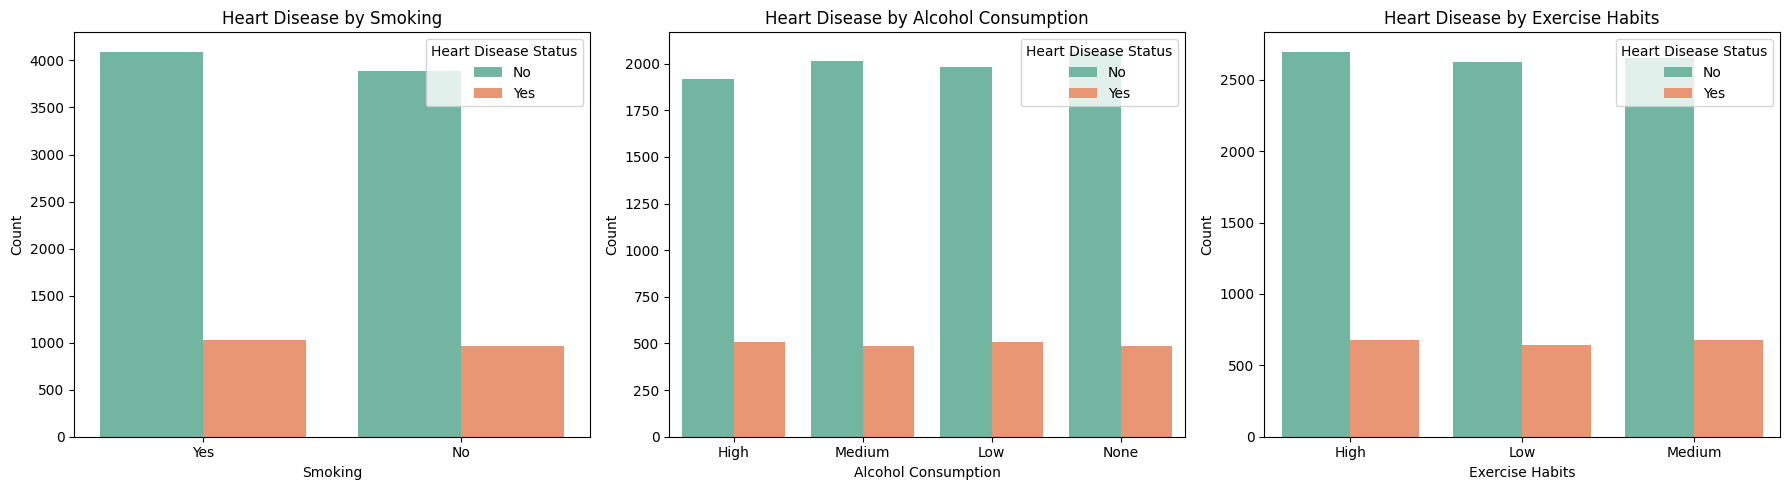

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 생활습관 변수들과 심장병 상태 간의 교차 분석 (비율 확인)
habit_cols = ['Smoking', 'Alcohol Consumption', 'Exercise Habits']

for col in habit_cols:
    print(f"\n--- {col} vs Heart Disease Status ---")
    # normalize='index'를 사용하여 각 그룹 내에서 Yes/No 비율을 확인합니다.
    ct = pd.crosstab(df[col], df['Heart Disease Status'], normalize='index') * 100
    display(ct.round(1))

# 2. 시각화 (Count Plot)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(habit_cols):
    sns.countplot(data=df, x=col, hue='Heart Disease Status', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Heart Disease by {col}')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Exercise Habits 컬럼의 분포를 value_counts()로 확인하기


In [38]:
df["Exercise Habits"].value_counts()

,count
Exercise Habits,
High,3372
Medium,3332
Low,3271


## 의료 해석 질문

- 어떤 수치형 변수의 평균 차이가 심장병 유무와 함께 먼저 보이나요?
- 생활습관 관련 범주형 변수 중 현업에서 추가 확인하고 싶은 항목은 무엇인가요?

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status',
       'Sleep Category'],
      dtype='object')

--- Stress Level vs Heart Disease Status ---


Heart Disease Status,No,Yes
Stress Level,,
High,80.2,19.8
Low,81.3,18.7
Medium,78.6,21.4



--- Sleep Category vs Heart Disease Status ---


Heart Disease Status,No,Yes
Sleep Category,,
Good (>=7h),80.2,19.8
Poor (<7h),79.8,20.2



--- Sugar Consumption vs Heart Disease Status ---


Heart Disease Status,No,Yes
Sugar Consumption,,
High,79.4,20.6
Low,80.2,19.8
Medium,80.5,19.5


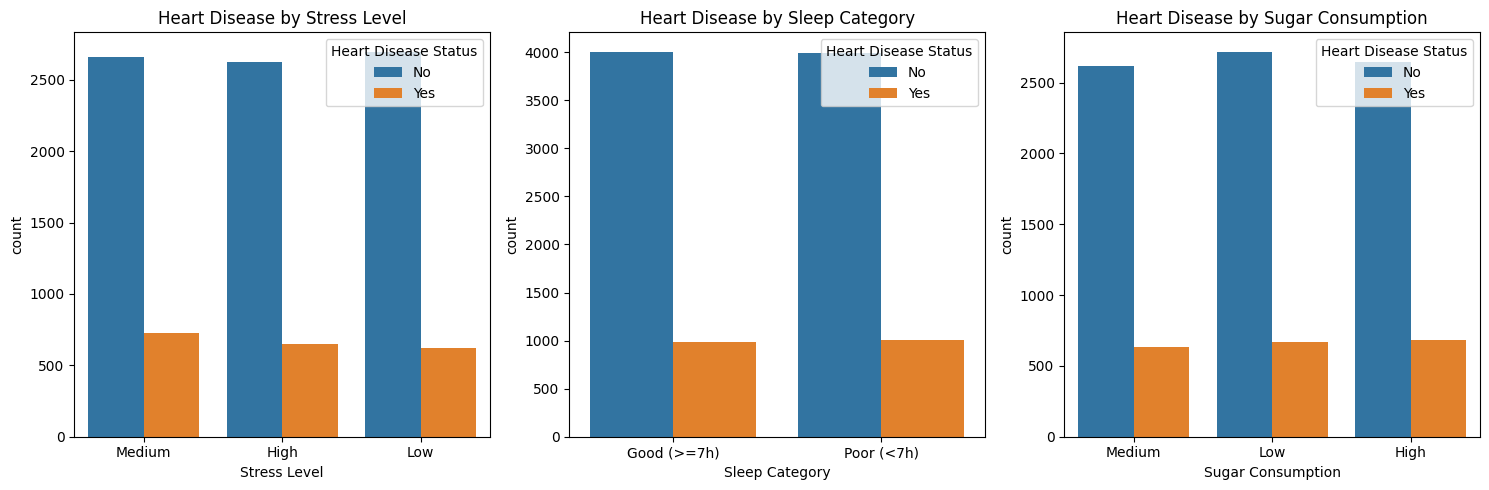

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print(df.columns)

df["Sleep Category"] = df['Sleep Hours'].apply(lambda x : 'Good (>=7h)' if x >= 7 else 'Poor (<7h)')

analysis_cols = ['Stress Level', 'Sleep Category', 'Sugar Consumption']

# 교차 분석
for col in analysis_cols:
  print(f"\n--- {col} vs Heart Disease Status ---")
  ct = pd.crosstab(df[col], df['Heart Disease Status'], normalize='index') * 100
  display(ct.round(1))

print()
# 시각화
flg, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(analysis_cols):
  sns.countplot(data=df, x=col, hue='Heart Disease Status', ax=axes[i])
  axes[i].set_title(f'Heart Disease by {col}')

plt.tight_layout()
plt.show()


### 📊 결과 해석 가이드

1. **Stress Level (스트레스 수준)**:
   - 스트레스 수준이 'High'인 그룹에서 심장병('Yes') 비율이 다른 그룹(Low, Medium)보다 눈에 띄게 높은지 확인합니다.
   - 만약 세 그룹의 비율이 비슷하다면, 이 데이터셋에서는 스트레스가 단독으로 심장병을 결정짓는 결정적인 요인은 아님을 시사합니다.

2. **Sleep Hours (수면 시간)**:
   - 일반적으로 수면 시간이 부족한('Poor') 그룹에서 심장병 발생 비율이 높게 나타나는 경향이 있는지 분석합니다.
   - `Sleep Category`를 통해 7시간 미만 수면자의 심장병 발생 빈도를 시각적으로 쉽게 비교할 수 있습니다.

3. **Sugar Consumption (설탕 섭취량)**:
    - 결정적인 요인이 아님을 알 수 있습니다.

4. **공통 사항**:
   - 전체 데이터에서 심장병이 없는('No') 환자가 대다수이므로, 막대의 절대적인 높이보다는 **'전체 막대 대비 주황색(Yes) 막대의 비율'**에 집중하여 해석하는 것이 중요합니다.